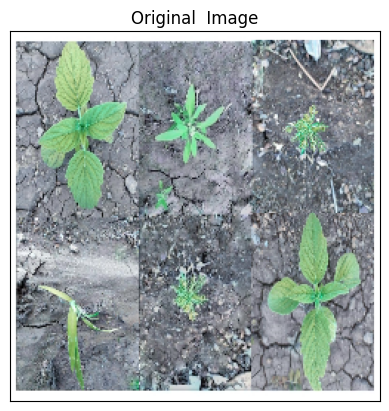

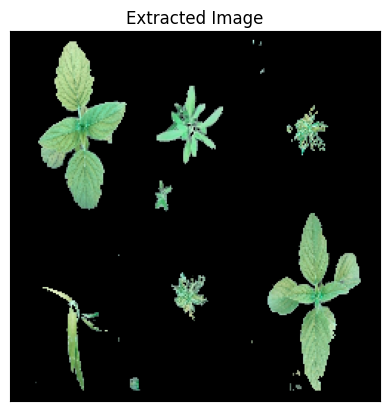

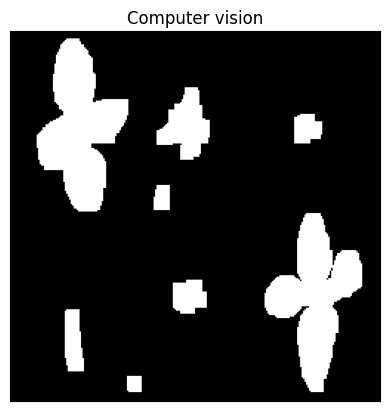

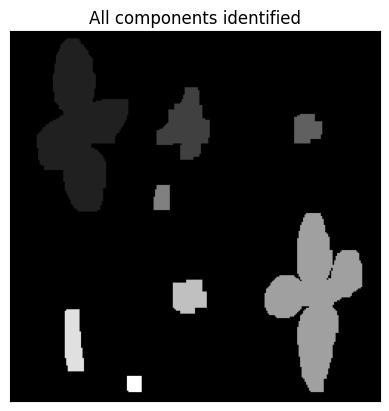

In [2]:
import cv2
import numpy as np 
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
import pandas as pd
np.set_printoptions(threshold=np.inf)
from sklearn.preprocessing import MinMaxScaler
#https://cvexplained.wordpress.com/2020/04/28/color-detection-hsv/
#https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html

scaler = MinMaxScaler()


def dtw_distance(s1, s2):
    """
    Calculate the Dynamic Time Warping distance between two arrays.
    
    Parameters:
    s1 (array): The first array.
    s2 (array): The second array.
    
    Returns:
    The DTW distance between the two arrays.
    """
    # Initialize the DTW matrix with very large values
    DTW = np.zeros((len(s1)+1, len(s2)+1))
    for i in range(len(s1)+1):
        for j in range(len(s2)+1):
            DTW[i, j] = float('inf')
    DTW[0, 0] = 0
    
    # Fill in the rest of the DTW matrix
    for i in range(1, len(s1)+1):
        for j in range(1, len(s2)+1):
            cost = abs(s1[i-1] - s2[j-1])
            DTW[i, j] = cost + min(DTW[i-1, j], DTW[i, j-1], DTW[i-1, j-1])
    
    # Return the DTW distance
    return DTW[len(s1), len(s2)]




def find_locations(arr):
    locations = []
    for i in range(len(arr)):
        currary = arr[i].copy()
        currary.sort()
        print("Min in array ", currary[1])
        j = arr[i].index(currary[1])
        locations.append({i, j})
                
    return locations



def getCommon(intSet):
    commList = []
    for currrLoc in range(len(intSet)):
        for otherLoc in range(len(intSet)-1-currrLoc):
            if(intSet[currrLoc].intersection(intSet[otherLoc+1+currrLoc])):
                commList.append(currrLoc)
                commList.append(otherLoc+1+currrLoc)
                return commList



def merge_related_objects(arr1, arr2):
    n = len(arr1)
    relation_map = {i: set() for i in range(n)}
    
    for i, related in enumerate(arr2):
        for j in related:
            relation_map[j].update(related)
    
    groups = []
    seen = set()
    
    for i in range(n):
        if i not in relation_map:
            groups.append([arr1[i]])
            seen.add(i)
        elif i not in seen:
            group = set(relation_map[i])
            group.add(i)
            groups.append(list(set(arr1[j] for j in group)))
            seen.update(group)
    
    return groups

orimage = cv2.imread('finalc.jpg')
(orirow, oricol) = orimage.shape[0:2]
compY = int(orirow/250) 
compX = int(oricol/250) 

image = cv2.resize(orimage, (250, 250))
bkpimage = image.copy()
#image = orimage.copy()

plt.imshow(image)
plt.title('Original  Image'), plt.xticks([]), plt.yticks([])
plt.show()


result = image.copy()
finalResult = image.copy()
image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
 

lowerg = np.array([35, 40, 20])
upperg = np.array([85, 255, 255])


green_mask = cv2.inRange(image, lowerg, upperg) 


 
result = cv2.bitwise_and(result, result, mask=green_mask)

 
gray_image = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)



(row, col) = gray_image.shape[0:2]
for i in range(row):
    for j in range(col):
        # Find the average of the BGR pixel values
        if (gray_image[i, j] > 0):
            gray_image[i, j] = 255
            

            
# Creating kernel
kernel = np.ones((5, 5), np.uint8)
  
# Using cv2.erode() method 
#gray_image = cv2.erode(gray_image, kernel) 

plt.imshow(result,cmap = 'gray')
plt.title('Extracted Image'), plt.xticks([]), plt.yticks([])
plt.show()

gray_image = cv2.erode(gray_image, kernel) 
gray_image = cv2.dilate(gray_image, kernel) 
gray_image = cv2.dilate(gray_image, kernel)
plt.imshow(gray_image,cmap = 'gray')
plt.title('Computer vision'), plt.xticks([]), plt.yticks([])
plt.show()



analysis  = cv2.connectedComponentsWithStats(gray_image)
(totalLabels, clsImage, values, centroid) = analysis

plt.imshow(clsImage ,cmap = 'gray')
plt.title('All components identified'), plt.xticks([]), plt.yticks([])
plt.show()


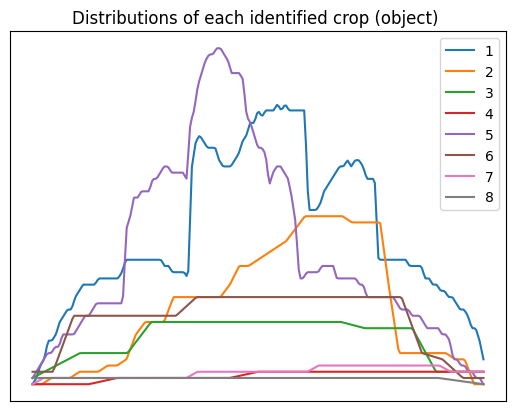

In [4]:

distrubutions = {}
localDistrubutions = {}
for eachObject in range (1,totalLabels):
    distrubutions.update({eachObject:[]})
    localDistrubutions.update({eachObject:0})




for i in range(row):
            for j in range(col):  
                if(clsImage[i, j]>0):
                    localDistrubutions.update({clsImage[i, j]:localDistrubutions.get(clsImage[i, j])+1})
            for intensity, instances in localDistrubutions.items():
                if (instances>0):
                    tempdist = list(distrubutions.get(intensity))
                    tempdist.append(instances)
                    distrubutions.update({intensity:tempdist })
                    localDistrubutions.update({intensity:0})
                    
new_size = 250                    
for intensity, instances in distrubutions.items():
    original_array = np.array(instances)
    f = interp1d(np.arange(original_array.size), original_array, kind='linear')
    new_array = f(np.linspace(0, original_array.size-1, new_size))
    distrubutions.update({intensity:new_array})
    
asdataFrame = pd.DataFrame(distrubutions)
asdataFrame.plot()
plt.title('Distributions of each identified crop (object) ',), plt.xticks([]), plt.yticks([])
plt.show()

distanceMatrix = []

for intensity1, instances1 in distrubutions.items():
    instanceDistance = []
    for intensity2, instances2 in distrubutions.items():
        dtw_dist = dtw_distance(instances1, instances2)
        instanceDistance.append(int(dtw_dist))
        #print("DTW distance between", intensity1," and ",intensity2,": ",dtw_dist)
    distanceMatrix.append(instanceDistance)
    


Min in array  520
Min in array  927
Min in array  580
Min in array  74
Min in array  520
Min in array  580
Min in array  74
Min in array  185
[{0, 4}, {1, 5}, {2, 5}, {3, 6}, {0, 4}, {2, 5}, {3, 6}, {3, 7}]
Total number of clusters:  3  list of clusters:  [[1, 5], [2, 3, 6], [8, 4, 7]]


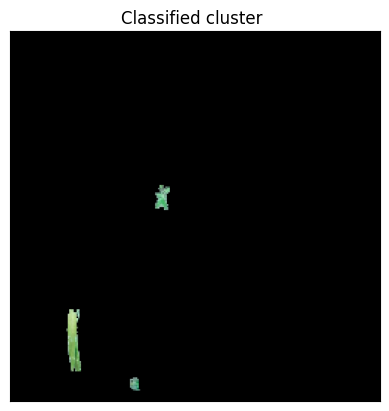

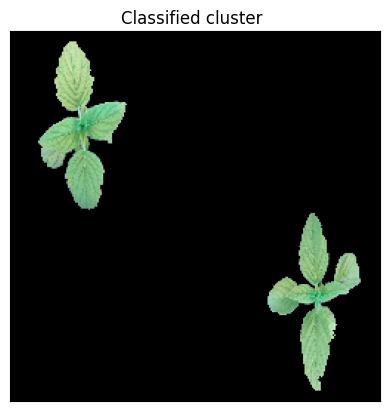

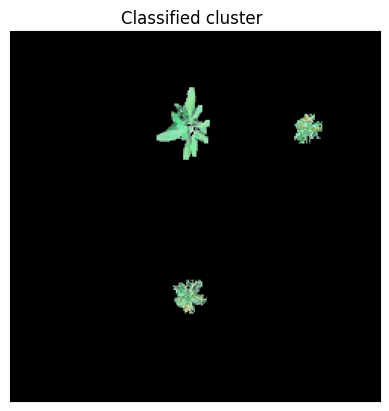

In [5]:
identifiedClusters = find_locations(distanceMatrix)
finalObjectList = list(range(1,totalLabels))

distanceMatrix
print(identifiedClusters)

commonList = getCommon(identifiedClusters)  
while(commonList!= None):
    list1 = identifiedClusters[commonList[0]]
    list2 = identifiedClusters[commonList[1]]
    identifiedClusters[commonList[0]] = list1.union(list2)
    identifiedClusters.remove(list2)
    commonList = getCommon(identifiedClusters)  




clusteLength = len(identifiedClusters)
clusterList = merge_related_objects(finalObjectList, identifiedClusters)
# for display convinenece
for eachset in identifiedClusters:
    
    maxZone = 0;
    for zone in eachset:
        if zone>maxZone:
            maxZone = zone
        
    
    #print(maxZone)
    for zone in eachset:
        #print("zone: ",finalObjectList[zone]," update: ",finalObjectList[maxZone])
        for i in range(row):
            for j in range(col):
                    if (clsImage[i, j] == finalObjectList[zone]):
                        clsImage[i, j] = finalObjectList[maxZone]
                        
classifiedObjects= set()
for i in range(row):
            for j in range(col):
                if (clsImage[i, j]>0):
                    classifiedObjects.add(clsImage[i, j])    

                    
                    
classifiedObjectsList = list(classifiedObjects)
print("Total number of clusters: ",len(classifiedObjectsList)," list of clusters: ",clusterList)



for cluster in classifiedObjectsList:
    dispimg = clsImage.copy()
    relimg = result.copy()
    for i in range(row):
            for j in range(col):
                if ((dispimg[i, j]>0) and (dispimg[i, j] != cluster)):
                    dispimg[i, j] = 0
                    
    for i in range(row):
            for j in range(col):
                if (dispimg[i, j] == 0):
                    relimg[i, j] = 0
                    
    
    #result = cv2.bitwise_and(result, result, mask=dispimg)
    plt.imshow(relimg,cmap = 'gray')
    plt.title('Classified cluster ',), plt.xticks([]), plt.yticks([])
    plt.show()


In [6]:
values


array([[    0,     0,   250,   250, 52338],
       [   18,     5,    62,   117,  3912],
       [   99,    38,    36,    49,  1039],
       [  192,    56,    19,    20,   322],
       [   97,   104,    11,    17,   176],
       [  172,   123,    66,   121,  3704],
       [  110,   168,    23,    23,   442],
       [   37,   188,    13,    42,   458],
       [   79,   233,    10,    11,   109]], dtype=int32)

In [7]:
areas = []
totalarea = 0
for eachCluster in clusterList:
    area = 0
    print(eachCluster)
    for eachInstance in eachCluster:
        area += values[eachInstance][4]   
    totalarea = totalarea+area
    areas.append(area)
                              

[1, 5]
[2, 3, 6]
[8, 4, 7]


In [8]:
areas

[7616, 1803, 743]

Cluster  1
Percent of Area occupied :  74.94587679590632


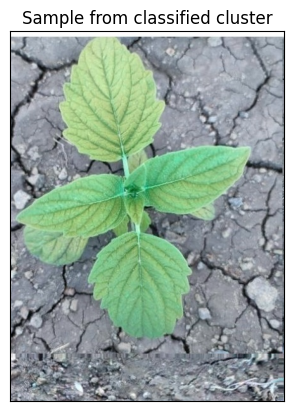

Cluster  2
Percent of Area occupied :  17.74257036016532


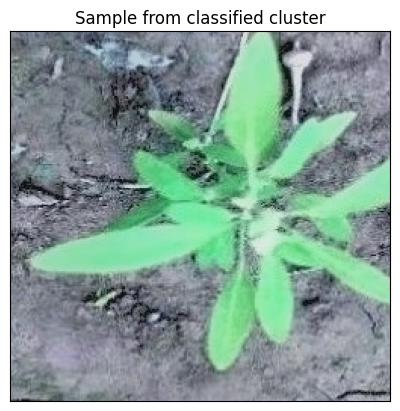

Cluster  3
Percent of Area occupied :  7.311552843928361


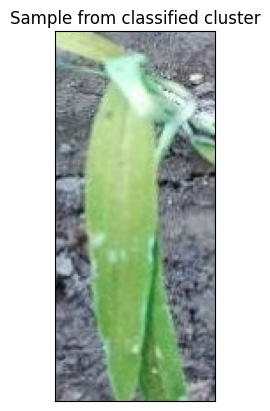

In [9]:
numb =1
for eachCluster in range(len(clusterList)):
    currItm = clusterList[eachCluster][0]
    maxarea = values[currItm][4]

    
    for eachinstance in clusterList[eachCluster]:
        if (values[eachinstance][4] > maxarea) :
            currItm = eachinstance
            maxarea = values[eachinstance][4]
    
    
    
    x, y, w, h, area = values[currItm]
    
    x= (compX) * x
    y= (compY) * y
    w= (compX+1) * w
    h= (compY+1) * h
    
 
   
    cropped = orimage[y:y+h, x:x+w]
    print("Cluster ", numb)
    print("Percent of Area occupied : ",(areas[eachCluster]/totalarea)*100)
    plt.imshow(cropped)
    plt.title('Sample from classified cluster'), plt.xticks([]), plt.yticks([])
    plt.show()
    numb = numb+1 

In [10]:
primaryCrop = 1

In [11]:
primaryCropIdx = primaryCrop -1
weedarea =  0
mainarea = 0
for eachclust in range(len(areas)):
    if eachclust == primaryCropIdx:
        mainarea = mainarea + areas[eachclust]
    else:
        weedarea = weedarea +  areas[eachclust]
        
weedPressure = weedarea/totalarea
finmage = cv2.imread('sprayer.jpg')
sprimage = cv2.resize(finmage, (oricol,orirow))
sprimage = cv2.cvtColor(sprimage, cv2.COLOR_BGR2RGB)
plt.imshow(sprimage)
plt.title('Image to be fed to sprayer'), plt.xticks([]), plt.yticks([])
print("Weed pressure is :",weedPressure)



error: OpenCV(4.8.1) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4062: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'


In [ ]:
distrubutions.get(1)


In [ ]:
arr_normalized = scaler.fit_transform((distrubutions.get(1)).reshape(-1, 1))

In [ ]:
arr_normalized

In [ ]:
array(arr_normalized)